# Detect Outliers 

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.discriminant_analysis import StandardScaler

In [2]:
RANDOM_STATE = 42
DATA_BASE_PATH = Path("./data")

rent_path = DATA_BASE_PATH / "apartments_for_rent_classified_10K.csv"

In [3]:
rent = pd.read_csv(rent_path, sep=";", encoding="latin1", dtype={"id": str})
rent.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [4]:
columns_to_check_for_outliers = [
    "price",
    "bedrooms",
    "bathrooms",
    "square_feet",
]

In [5]:
rent = rent[columns_to_check_for_outliers].copy()

In [6]:
rent = rent.dropna()
rent = rent.reset_index(drop=True)
rent.describe()

,price,bedrooms,bathrooms,square_feet
count,9960.000000,9960.000000,9960.000000,9960.000000
mean,1487.090763,1.746988,1.380321,942.916767
std,1077.009033,0.941315,0.615212,526.463071
min,200.000000,0.000000,1.000000,107.000000
25%,949.000000,1.000000,1.000000,650.000000
50%,1274.500000,2.000000,1.000000,803.000000
75%,1695.000000,2.000000,2.000000,1100.000000
max,52500.000000,9.000000,8.500000,11318.000000


## Isolation Forest

In [7]:
rent_isolation_forest = rent.copy()

In [8]:
def isolation_forest_outlier_detection(
    df: pd.DataFrame, columns: list[str]
) -> pd.Series:
    """
    Detect outliers using Isolation Forest algorithm.
    """
    numeric = df[columns].select_dtypes(include=["float64", "int64"]).dropna()

    scaler = StandardScaler()
    numeric_scaled = scaler.fit_transform(numeric)

    clf = IsolationForest(contamination="auto", random_state=RANDOM_STATE)
    predict = clf.fit_predict(numeric_scaled)

    # Convert -1 (outlier) to True and 1 (inlier) to False
    return pd.Series(predict, index=numeric.index, name="outliers")

In [9]:
outliers = isolation_forest_outlier_detection(
    rent_isolation_forest, columns_to_check_for_outliers
)
rent_isolation_forest["outlier"] = outliers
rent_isolation_forest["outlier"].value_counts()

outlier
 1    8314
-1    1646
Name: count, dtype: int64

In [10]:
def plot_outliers(data, feature):
    plt.figure(figsize=(10, 6))
    plt.title(f"Outliers in {feature}")
    plt.scatter(data.index, data[feature], color="blue", label="Data")
    plt.scatter(
        data[data["outlier"] == -1].index,
        data[data["outlier"] == -1][feature],
        color="red",
        label="Outliers",
        alpha=0.05,
    )
    plt.xlabel("Index")
    plt.ylabel(feature)
    plt.legend()
    plt.show()

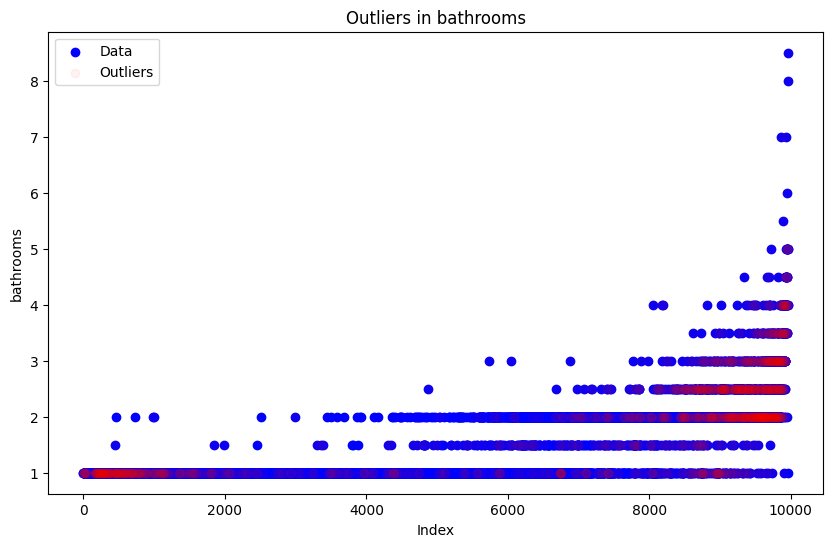

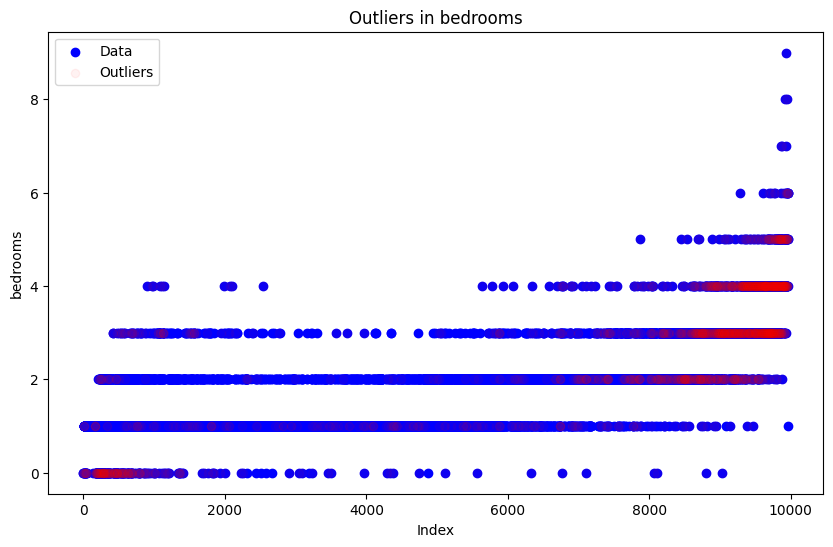

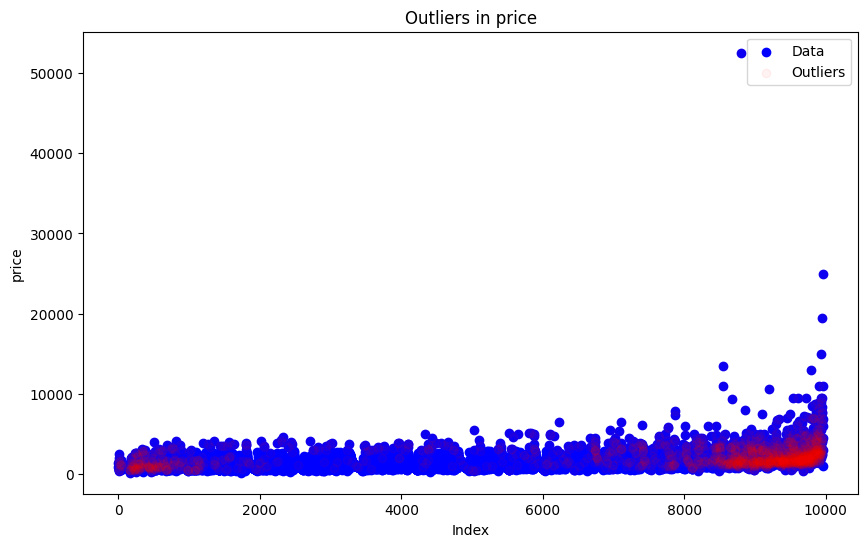

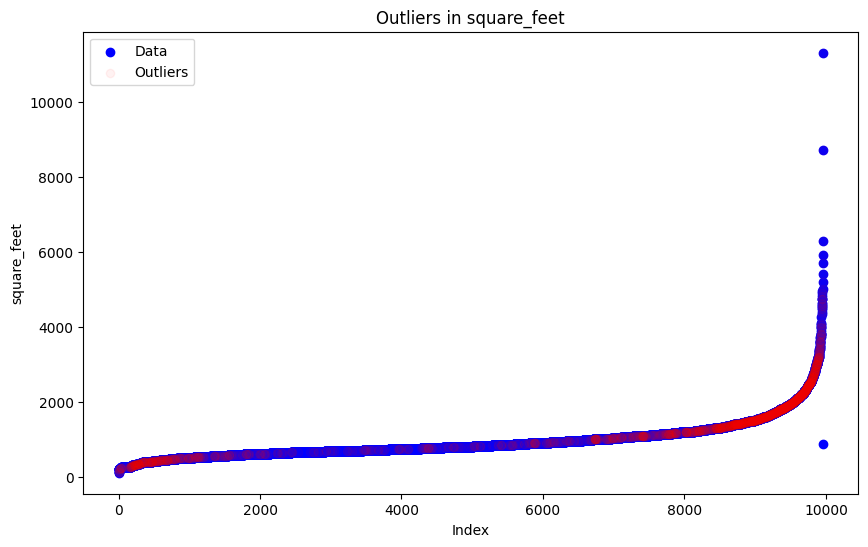

In [11]:
plot_outliers(rent_isolation_forest, "bathrooms")
plot_outliers(rent_isolation_forest, "bedrooms")
plot_outliers(rent_isolation_forest, "price")
plot_outliers(rent_isolation_forest, "square_feet")

In [23]:
def plot_pairplot_outliers(
    df: pd.DataFrame,
    columns: list[str],
    outlier_col: str = "outlier",
    aplha: float = 0.1,
):
    sns.pairplot(
        df,
        vars=columns,
        hue=outlier_col,
        palette={-1: "red", 1: "blue"},
        plot_kws={"alpha": aplha, "s": 10},
    )
    plt.gcf().set_size_inches(12, 10)
    plt.gcf().set_dpi(100)
    plt.suptitle("Pairplot of Outliers in N Dimensions", y=1.02)
    plt.show()

In [13]:
def iqr_outlier_bounds(series: pd.Series) -> tuple[float, float]:
    """
    Calculate the IQR outlier bounds for a given series.
    The function returns a tuple with the lower and upper bounds.
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return lower_bound, upper_bound

In [14]:
iqr_outliers_mask = (
    rent_isolation_forest[columns_to_check_for_outliers]
    .apply(lambda col: ~col.between(*iqr_outlier_bounds(col)), axis=0)
    .any(axis=1)
)

isolation_outliers_mask = (
    rent_isolation_forest["outlier"] == -1
)  # -1 são outliers no IsolationForest

intersection = iqr_outliers_mask & isolation_outliers_mask
only_iqr = iqr_outliers_mask & ~isolation_outliers_mask
only_isolation = isolation_outliers_mask & ~iqr_outliers_mask

print("Total IQR:", iqr_outliers_mask.sum())
print("Total Isolation Forest:", isolation_outliers_mask.sum())
print("Interseção:", intersection.sum())
print("Somente IQR:", only_iqr.sum())
print("Somente Isolation:", only_isolation.sum())

Total IQR: 1181
Total Isolation Forest: 1646
Interseção: 1049
Somente IQR: 132
Somente Isolation: 597


In [28]:
def plot_isolation_forest_pca_projection(
    components: np.ndarray, outlier_labels: pd.Series
):
    """
    Plot PCA projection of data colored by Isolation Forest outlier labels.

    Args:
        components (np.ndarray): 2D PCA components (shape: [n_samples, 2]).
        outlier_labels (pd.Series or np.ndarray): Outlier labels (-1 for outlier, 1 for inlier).
    """
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(
        components[:, 0], components[:, 1], c=outlier_labels, cmap="coolwarm", alpha=0.5
    )
    plt.title("Outliers via Isolation Forest (PCA projection)")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.colorbar(scatter, label="Outlier (-1) vs Inlier (1)")
    plt.show()

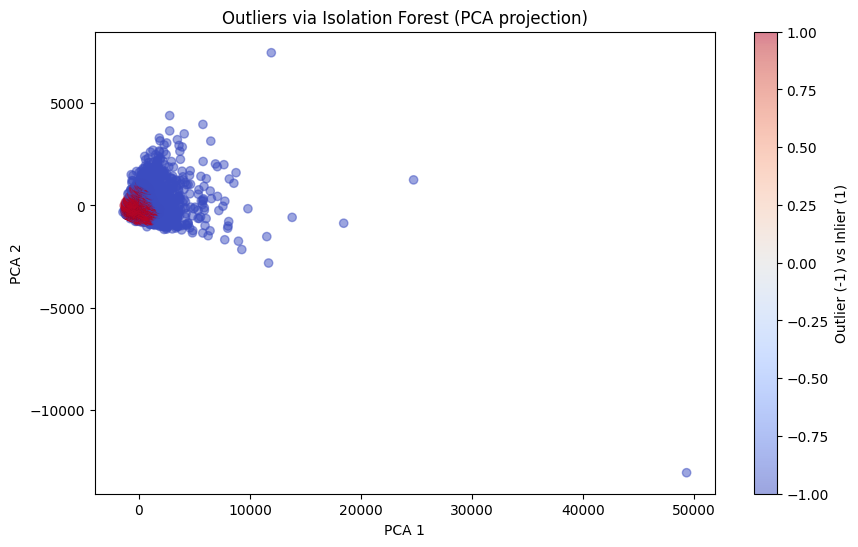

In [29]:
plot_isolation_forest_pca_projection(
    PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(
        rent_isolation_forest[columns_to_check_for_outliers]
    ),
    rent_isolation_forest["outlier"],
)

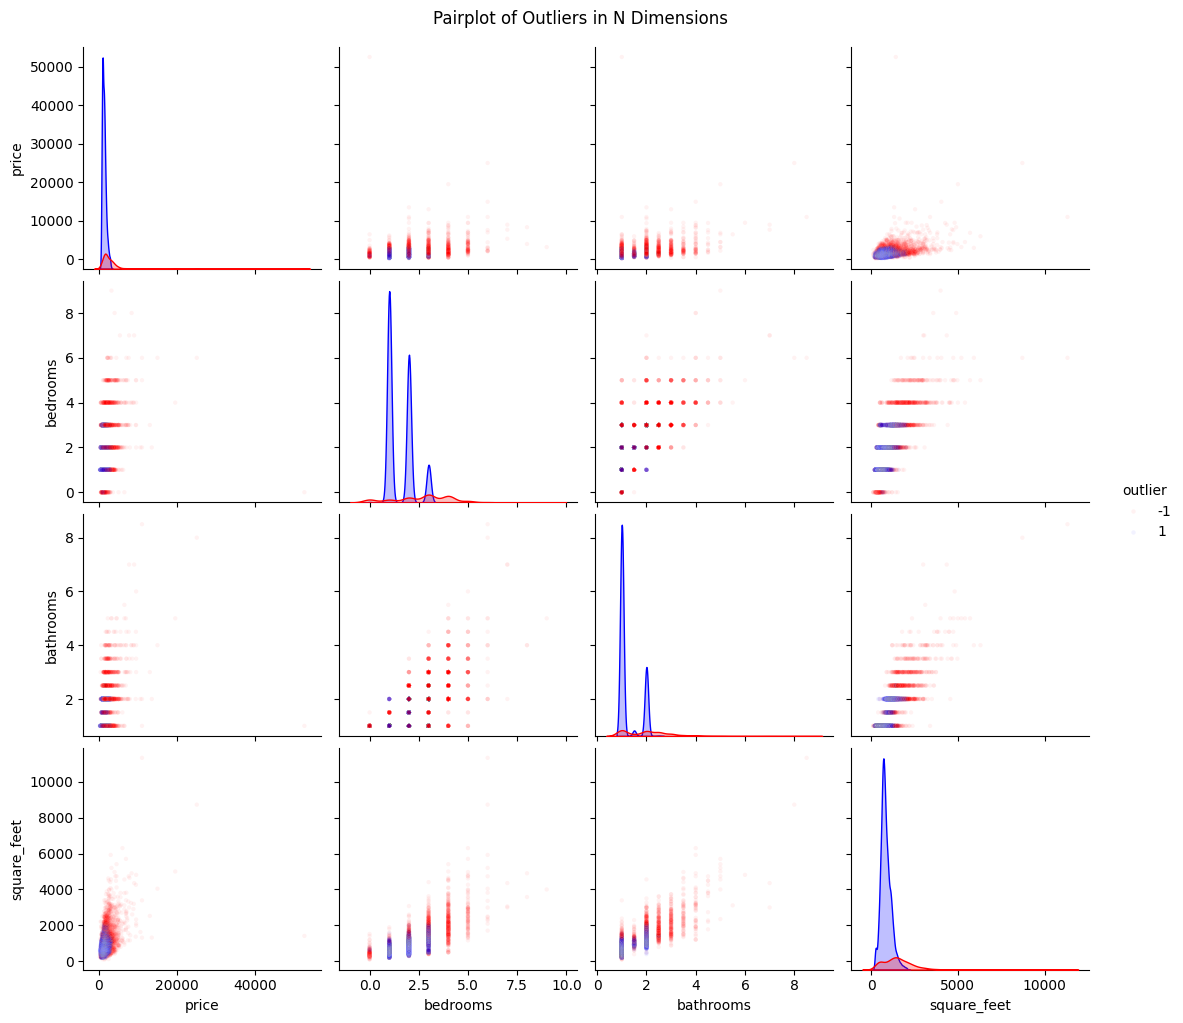

In [26]:
plot_pairplot_outliers(
    rent_isolation_forest,
    columns_to_check_for_outliers,
    outlier_col="outlier",
    aplha=0.05,
)

## LOF (Local Outlier Factor)

In [19]:
rent_lof = rent.copy()

In [38]:
def lof_outlier_detection(df: pd.DataFrame, columns: list[str]) -> pd.Series:
    """
    Detect outliers using Local Outlier Factor (LOF) algorithm.
    """

    numeric = df[columns].select_dtypes(include=["float64", "int64"]).dropna()

    scaler = StandardScaler()
    numeric_scaled = scaler.fit_transform(numeric)

    clf = LocalOutlierFactor(contamination="auto")
    predict = clf.fit_predict(numeric_scaled)

    # Convert -1 (outlier) to True and 1 (inlier) to False
    return pd.Series(predict, index=numeric.index, name="outliers")

In [39]:
outliers = lof_outlier_detection(rent_lof, columns_to_check_for_outliers)
rent_lof["outlier"] = outliers
rent_lof["outlier"].value_counts()

outlier
 1    9658
-1     302
Name: count, dtype: int64

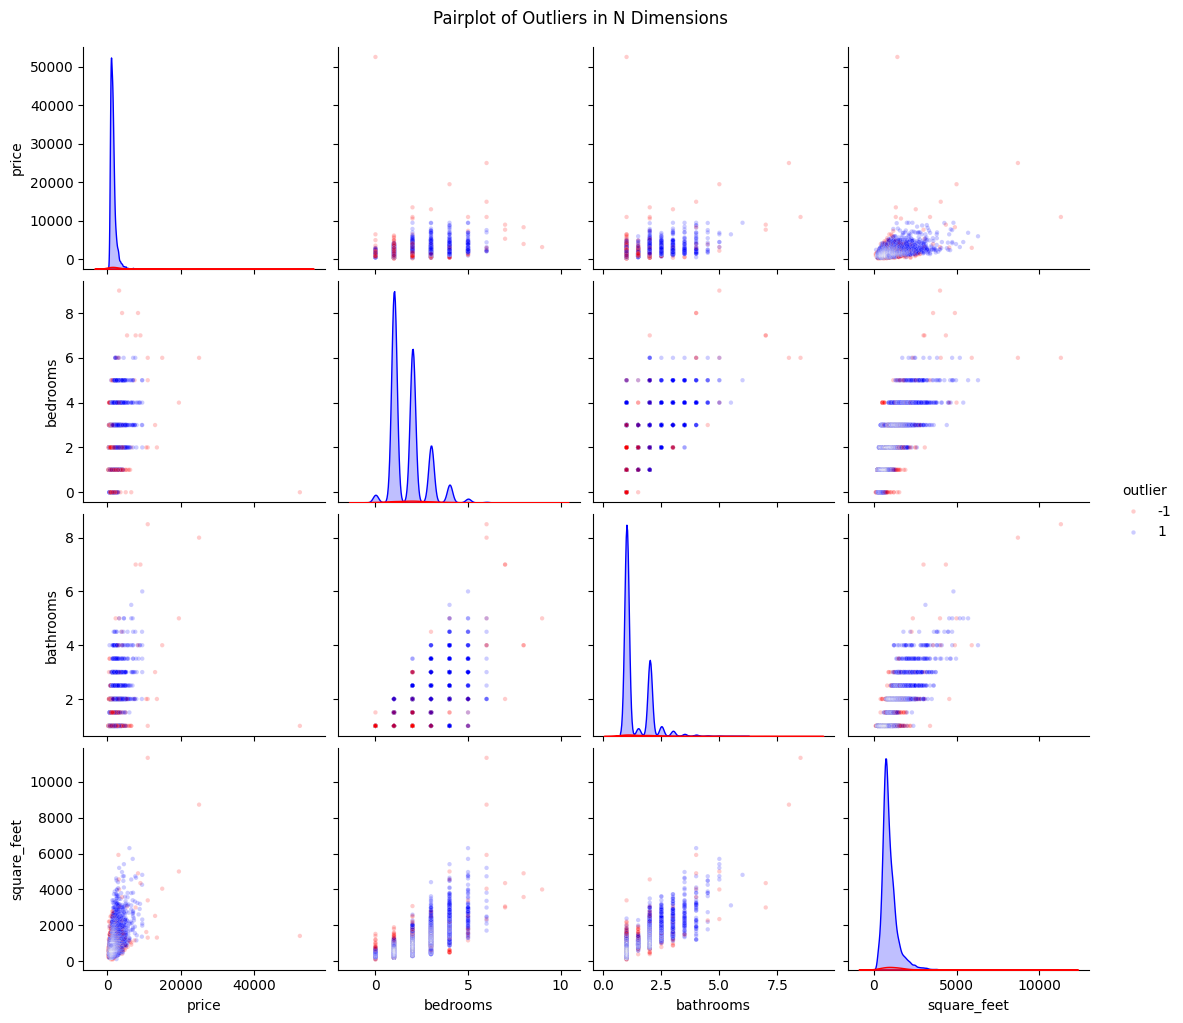

In [40]:
plot_pairplot_outliers(rent_lof, columns_to_check_for_outliers, aplha=0.2)

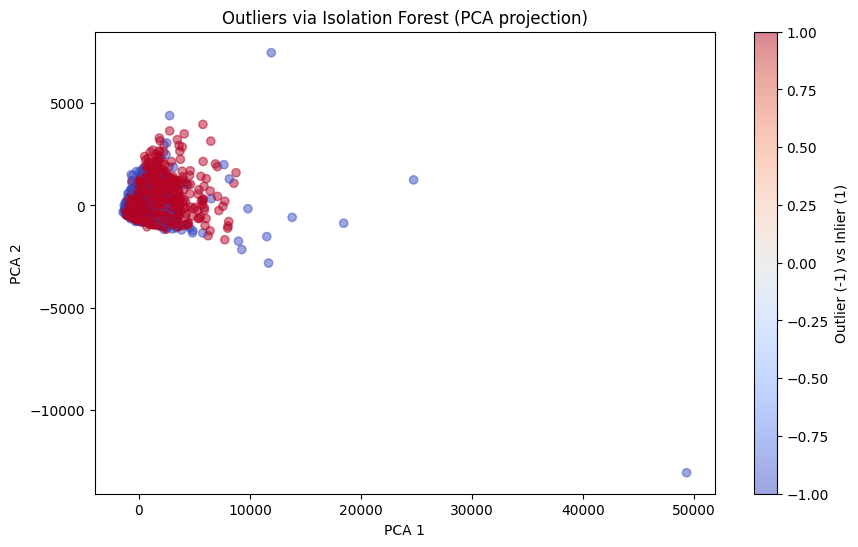

In [41]:
plot_isolation_forest_pca_projection(
    PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(
        rent_lof[columns_to_check_for_outliers]
    ),
    rent_lof["outlier"],
)

In [42]:
# Count outliers detected by Isolation Forest
isolation_outlier_count = (rent_isolation_forest["outlier"] == -1).sum()
print(f"Isolation Forest outliers: {isolation_outlier_count}")

# Count outliers detected by Local Outlier Factor (LOF)
lof_outlier_count = (rent_lof["outlier"] == -1).sum()
print(f"LOF outliers: {lof_outlier_count}")

# Count intersection of outliers detected by both methods
intersection_count = (
    (rent_isolation_forest["outlier"] == -1) & (rent_lof["outlier"] == -1)
).sum()
print(f"Intersection (both methods): {intersection_count}")

Isolation Forest outliers: 1646
LOF outliers: 302
Intersection (both methods): 196
